In [3]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
# import seaborn as sns 

# import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.stats import gaussian_kde

In [ ]:
# Uncomment to install kaleido for saving files
# %conda install -c conda-forge python-kaleido

In [4]:
dfx = pd.read_csv('exp1_search_space.csv')
# limit to budget = 300
dfx = dfx[dfx.time<=300]
dfx['num_replicates'] = dfx.groupby(['method', 'p1', 'p2']).cumcount() + 1
# include initial design 

dfx_init = dfx[dfx.iter==1].drop_duplicates(subset=['p1', 'p2', 'num_replicates'])
dfx_init['method'] = "Initial Design"

dfx = pd.concat([dfx, dfx_init])
dfx.head()

,p1,p2,rep,rmse,method,time,iter,num_replicates
0,0.841195,0.835311,1,43.450438,fCRN,1,1,1
1,0.841195,0.835311,2,41.686477,fCRN,2,1,2
2,0.841195,0.835311,3,59.818951,fCRN,3,1,3
3,0.841195,0.835311,4,20.534684,fCRN,4,1,4
4,0.841195,0.835311,5,42.003772,fCRN,5,1,5


In [22]:
all_methods = [['Initial Design', 'fHet', 'aHet'],
               ['fgCRN', 'fCRN', 'aCRN']]
n=6
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'surface'}]*3, [{'type':'surface'}]*3],
    subplot_titles=all_methods[0]+all_methods[1],
    horizontal_spacing=0,   # shrink gutters 
    vertical_spacing=0
)

# camera = dict(
#     eye=dict(x=1.7,   # out to the right
#              y=-1.2,  # pulled forward
#              z=0.9),  # lifted up
#     up=dict(x=0, y=0, z=1)  # ensure “up” is along the z–axis
# )
camera = dict(
    eye=dict(x=1,   # out to the right
             y=-2.2,  # pulled forward
             z=0.9),  # lifted up
    up=dict(x=0, y=0, z=1)  # ensure “up” is along the z–axis
)



# Prepare the plane at x = 10, over p1,p2 ∈ [0,1]
x0 = 10
grid_n = 10
p1_lin = np.linspace(0, 1, grid_n)
p2_lin = np.linspace(0, 1, grid_n)
P1, P2 = np.meshgrid(p1_lin, p2_lin)
X = np.full_like(P1, x0)

rep_val = 'rep'
ground_truth = {'p1':0.45, 'p2':0.35, 'rep':30}

for i, methods in enumerate(all_methods, start=1):
    for j, method in enumerate(methods, start=1):
        dfm = dfx[(dfx['method']==method)]
        if method != 'Initial Design':
            dfm = dfm[dfm.iter>1]

        # build a color list: blue if <20, red otherwise
        colors = ['tomato' if rr <= 20 else 'tomato' for rr in dfm['num_replicates']]

        if method.endswith("Het"):
            range_max = dfx[rep_val].max()
        else:
            range_max = 55
        
        gt_x = np.linspace(0,range_max)
        gt_y = np.full_like(gt_x,ground_truth["p1"])
        gt_z = np.full_like(gt_x,ground_truth["p2"])
        
        fig.add_trace(
            go.Scatter3d(
                x = dfm[rep_val],
                y = dfm['p1'],
                z = dfm['p2'],
                mode = 'markers',
                marker = dict(
                    size = 3,
                    color = colors,
                    opacity=1
                ),
                showlegend = False
            ),
            row=i, col=j
        )
        fig.add_trace(
            go.Scatter3d(
                x=[ground_truth['rep']],
                y=[ground_truth['p1']],
                z=[ground_truth['p2']],
                mode='markers',
                marker = dict(
                    size=4,
                    color='black'
                ),
                showlegend=False
            ),
            row=i, col=j
        )
        fig.add_trace(
            go.Scatter3d(
                x=gt_x,
                y=gt_y,
                z=gt_z,
                mode='lines',
                marker = dict(
                    size=2,
                    color='black'
                ),
                showlegend=False
            ),
            row=i, col=j
        )
        fig.add_trace(
            go.Surface(
                x = X, y = P1, z = P2,
                # make all values in this matrix the same (e.g. zeros)
                surfacecolor = np.zeros_like(P1),
                # map “0” → light-green; “1” → light-green (so it’s uniform)
                colorscale = [[0,'cornflowerblue'], [1, 'cornflowerblue']],
                opacity    = 0.5,
                showscale  = False,
                showlegend = False
            ),
            row=i, col=j
        )

       

        fig.update_scenes(
            dict(
                # overall scene background
                bgcolor='white',
                aspectmode='cube',
                # x-axis (num_replicates), descending
                xaxis=dict(
                    range=[range_max, -1],
                    title='replicate',
                    showgrid=True,    # no grid‐planes
                    zeroline=False,    # no zero‐plane
                    showline=True,     # draw the axis line
                    mirror=True,       # mirror that line on the opposite side of the box
                    linewidth=2,       # thickness
                    linecolor='black',  # color of the box edges
                    showticklabels=False,
                    backgroundcolor='white'

                ),
                # y-axis (p1)
                yaxis=dict(
                    title='β',
                    range=[0, 1],
                    showgrid=False,
                    zeroline=False,
                    showline=True,
                    mirror=True,
                    linewidth=2,
                    linecolor='black',
                    showticklabels=False,
                    backgroundcolor='white',
                    tickfont = dict(size=14)
            
                ),
                # z-axis (p2)
                zaxis=dict(
                    range=[0, 1],
                    title='γ',
                    showgrid=False,
                    zeroline=False,
                    showline=True,
                    mirror=True,
                    linewidth=2,
                    linecolor='black',
                    showticklabels=False,
                    backgroundcolor='white'
                ),
                camera = camera
            ),
            row=i, col=j
        )

        

annos = []
for i, methods in enumerate(all_methods):
    for j, method in enumerate(methods):
        x = (j + 0.5)/3 
        if i == 0:
            y = .925
        elif i == 1:
            y = .425
        annos.append(dict(
            text=method,
            x=x, y=y,          # just above the top of the plot
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=18),
        ))
    
fig.update_layout(
    width = 150 * n,              # ← bump per‐panel width
    height = 600,                 # ← bump height for more vertical space
    margin = dict(l=0, r=0, t=50, b=0),  # trim outer margins
    paper_bgcolor='white',
    annotations=annos,
)


    
fig.show()

(JO) For Figure 7, current idea is to have two figures, one for the main paper and one for the appendix

* Main paper, Show 2 3d panels for fHet and aCRN (the top two performers) and 2 top down (2d) panels for them demonstrating the theta spread in the aCRN compared to fHet
* Appendix, show the 6 panel 3d figure that we currently have in the main paper, we can also include the top down view for all 6 in the appendix.

In [23]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "aCRN"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

In [24]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "fHet"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

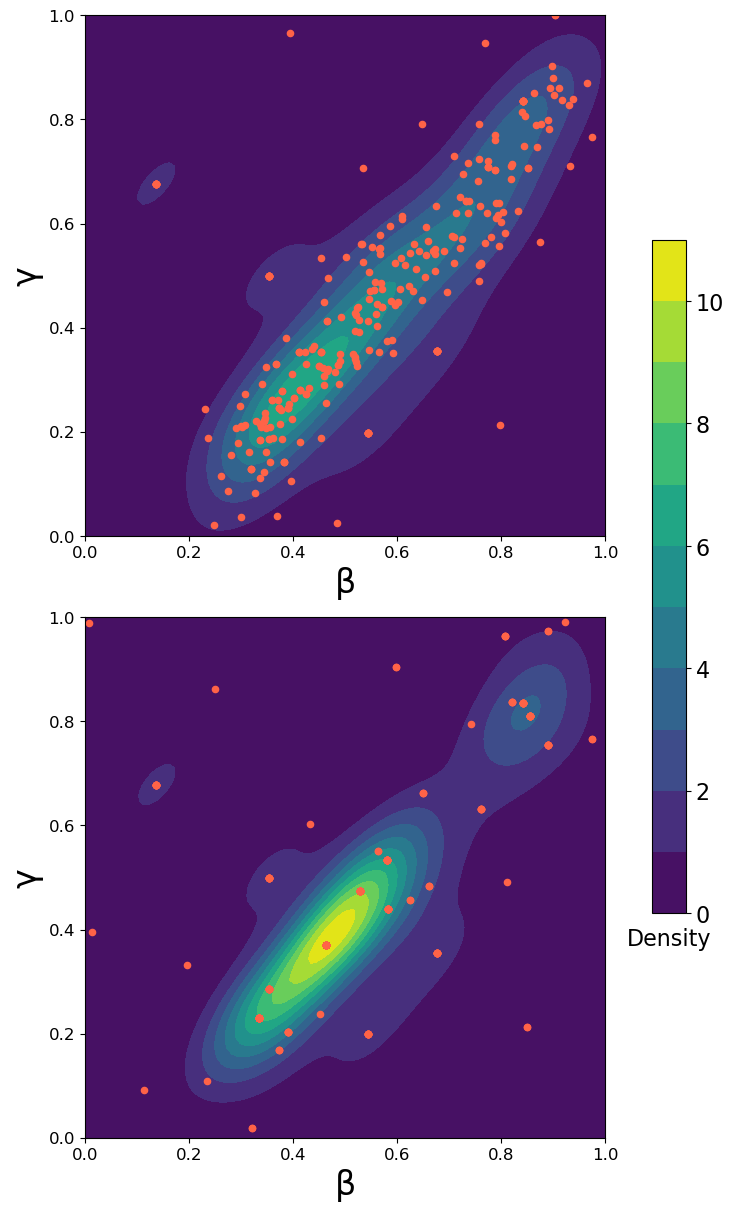

In [11]:
# Create the figure and subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 12), constrained_layout=True)

methods = ['aCRN', 'fHet']

for i, method in enumerate(methods):


    dfm = dfx[(dfx['method']==method)]
    df = dfm

    # Extract x and y values
    x = df['p1']
    y = df['p2']

    # Perform kernel density estimation
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)

    # Create a grid for the contour plot
    x_grid, y_grid = np.meshgrid(
        np.linspace(0, 1, 100),  # Set x limits from 0 to 1
        np.linspace(0, 1, 100)   # Set y limits from 0 to 1
    )


    # Evaluate the density on the grid
    z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
    # Define fixed density levels for the contour plot
    density_levels = np.linspace(0, 11, 12)  # 12 fixed levels

    # Create the contour plot
    # axes[i].figure(figsize=(8, 6))
    p = axes[i].contourf(x_grid, y_grid, z, levels=density_levels, cmap='viridis' )
    axes[i].scatter(x, y, s=20, color='tomato', alpha=1, label='Data Points')

    axes[i].set_xlabel('β', fontsize=24)
    axes[i].set_ylabel('γ', fontsize=24)
    # axes[i].set_title(method)
    axes[i].set_aspect('equal', 'box')
    axes[i].tick_params(axis='both', which='major', labelsize=12) 


cbar = fig.colorbar(p, ax=axes[:], shrink=0.6)
cbar.ax.set_xlabel('Density', labelpad=10, fontsize = 16)
cbar.ax.tick_params(labelsize=16)

plt.savefig("density_pair.png")
plt.show()




Create the density plot for all 6 methods for appendix

Initial Design
0
fHet
1
aHet
2
fgCRN
3
fCRN
4
aCRN
5


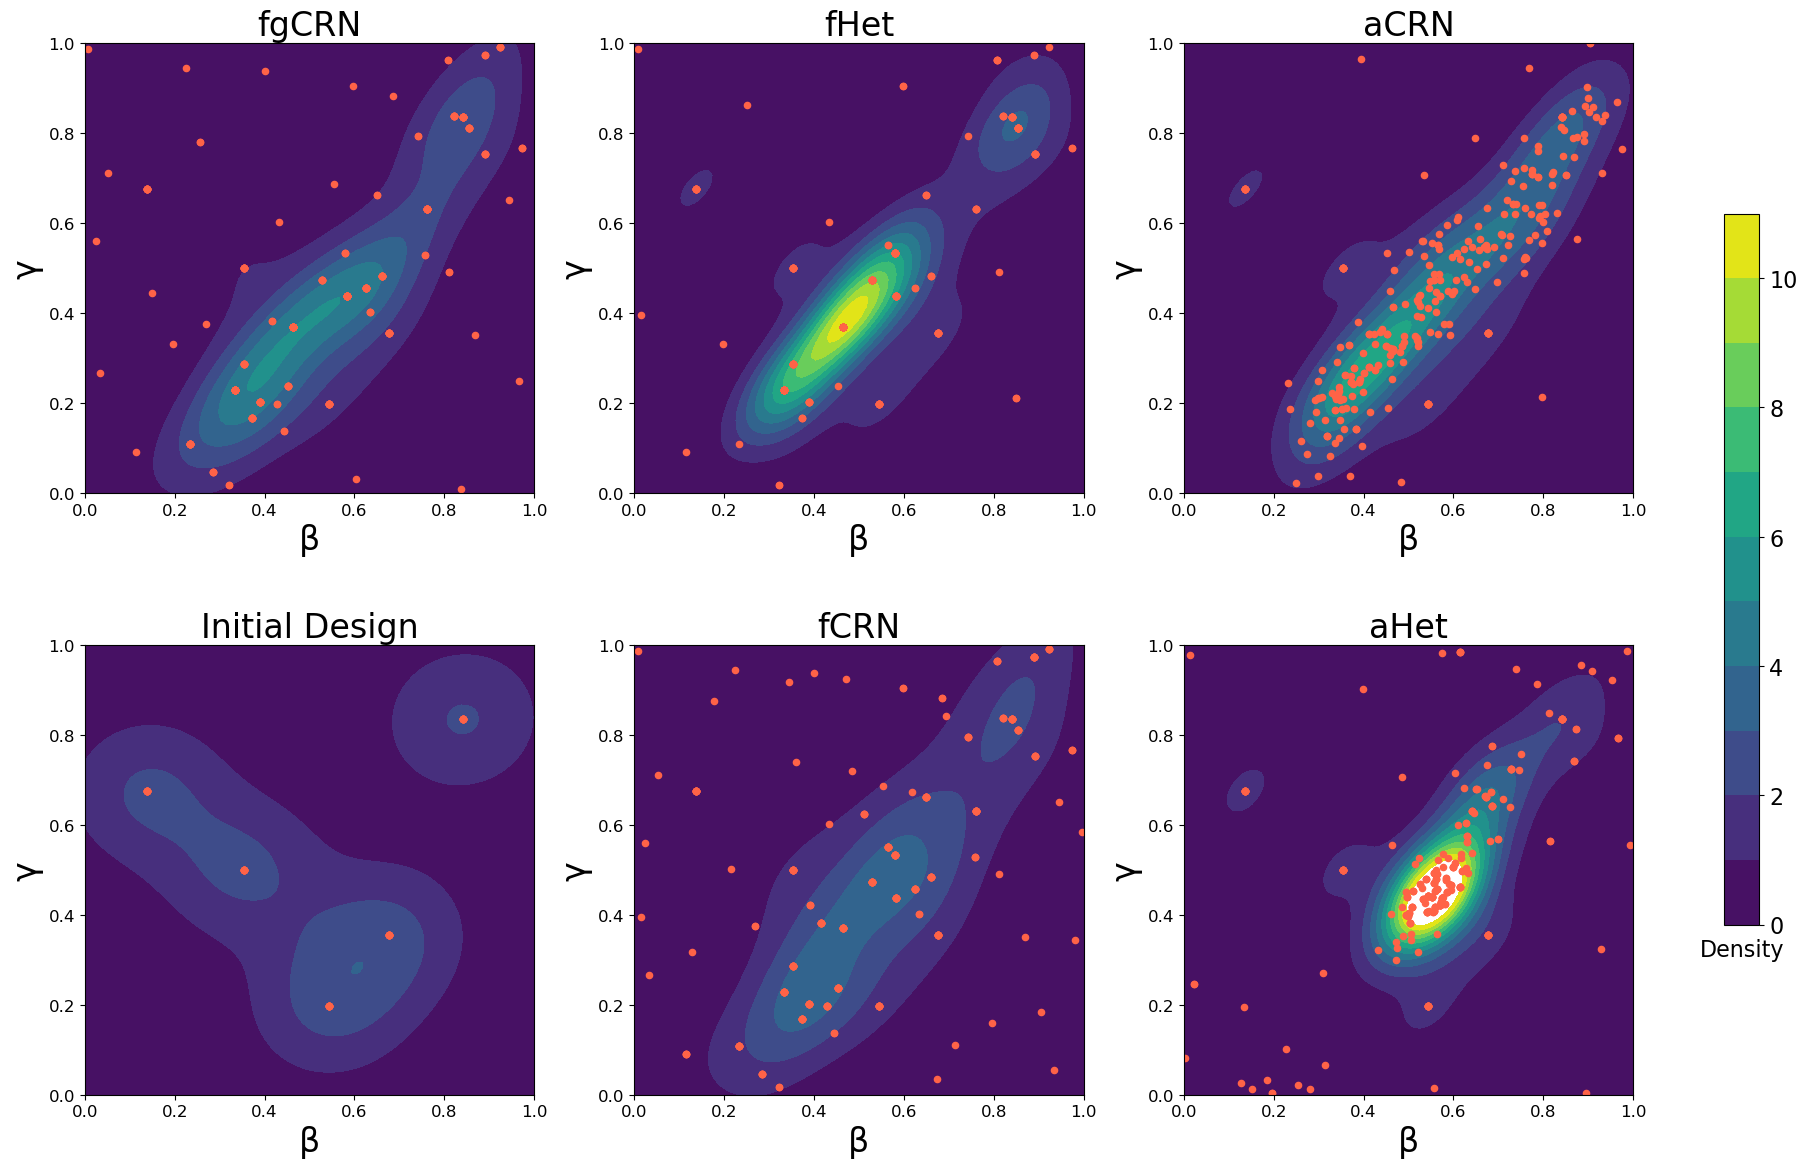

In [12]:
# Create the figure and subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

methods = ['Initial Design', 'fHet', 'aHet', 'fgCRN', 'fCRN', 'aCRN']

for i, method in enumerate(methods):

    print(method)
    print(i)

    dfm = dfx[(dfx['method']==method)]
    df = dfm

    # Extract x and y values
    x = df['p1']
    y = df['p2']

    # Perform kernel density estimation
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)

    # Create a grid for the contour plot
    x_grid, y_grid = np.meshgrid(
        np.linspace(0, 1, 100),  # Set x limits from 0 to 1
        np.linspace(0, 1, 100)   # Set y limits from 0 to 1
    )


    # Evaluate the density on the grid
    z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
    # Define fixed density levels for the contour plot
    density_levels = np.linspace(0, 11, 12)  # 12 fixed levels

    # Create the contour plot
    # axes[i].figure(figsize=(8, 6))
    n = i % 3
    m = i % 2 - 1
    p = axes[m, n].contourf(x_grid, y_grid, z, levels=density_levels, cmap='viridis', )
    # axes[i].legend()
    # plt.colorbar(label='Density')
    # plt.colorbar()
    axes[m, n].scatter(x, y, s=20, color='tomato', alpha=1, label='Data Points')
    axes[m, n].set_xlabel('β', fontsize=24)
    axes[m, n].set_ylabel('γ', fontsize=24)
    axes[m, n].set_title(method, fontsize = 24)
    axes[m, n].set_aspect('equal', 'box')
    axes[m, n].tick_params(axis='both', which='major', labelsize=12) 


cbar = fig.colorbar(p, ax=axes[:], shrink=0.6)
cbar.ax.set_xlabel('Density', labelpad=10, fontsize = 16)
cbar.ax.tick_params(labelsize=16)


plt.savefig("density_all_6.png")
plt.show()

In [25]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "fCRN"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

In [26]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "fgCRN"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

In [27]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "aHet"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

In [29]:
import importlib
import create_3d_plot_single #import the module here, so that it can be reloaded.
importlib.reload(create_3d_plot_single)
from create_3d_plot_single import plot_single_3d # or whatever name you want.

method = "Initial Design"
# fig = plot_single_3d(dfx, method=method, outfile=method+"_def.png")
fig = plot_single_3d(dfx, method=method, width=660, height = 800, outfile=method+"_660_800.png",
                    dot_size=3,
                     eye_dict=dict(x=1.3, y=-2.2, z=0.9),
                     margin_dict=dict(l=0, r=0, t=0, b=0))

---






Extras below, e.g., attempt at using the geom_tile approach in plotnine

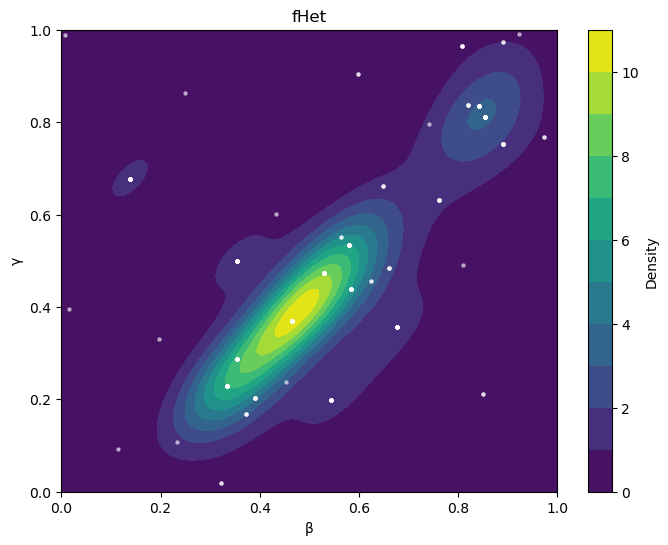

In [6]:

method = 'fHet'

dfm = dfx[(dfx['method']==method)]
df = dfm

# Extract x and y values
x = df['p1']
y = df['p2']

# Perform kernel density estimation
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Create a grid for the contour plot
x_grid, y_grid = np.meshgrid(
    np.linspace(0, 1, 100),  # Set x limits from 0 to 1
    np.linspace(0, 1, 100)   # Set y limits from 0 to 1
)


# Evaluate the density on the grid
z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
# Define fixed density levels for the contour plot
density_levels = np.linspace(0, 11, 12)  # 12 fixed levels

# Create the contour plot
plt.figure(figsize=(8, 6))
plt.contourf(x_grid, y_grid, z, levels=density_levels, cmap='viridis')
plt.colorbar(label='Density')
# plt.colorbar()
plt.scatter(x, y, s=5, color='white', alpha=0.5, label='Data Points')
plt.xlabel('β')
plt.ylabel('γ')
plt.title(method)
# plt.legend()
plt.show()

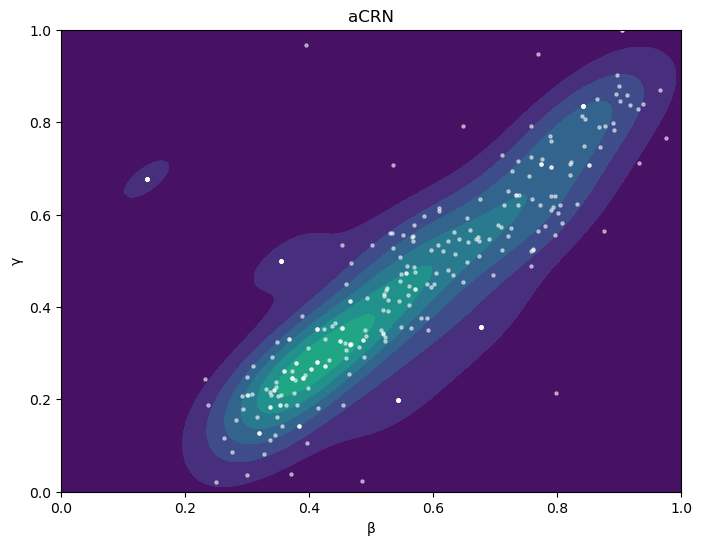

In [7]:

method = 'aCRN'

dfm = dfx[(dfx['method']==method)]
df = dfm

# Extract x and y values
x = df['p1']
y = df['p2']

# Perform kernel density estimation
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Create a grid for the contour plot
x_grid, y_grid = np.meshgrid(
    np.linspace(0, 1, 100),  # Set x limits from 0 to 1
    np.linspace(0, 1, 100)   # Set y limits from 0 to 1
)


# Evaluate the density on the grid
z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
# Define fixed density levels for the contour plot
density_levels = np.linspace(0, 11, 12)  # 12 fixed levels

# Create the contour plot
plt.figure(figsize=(8, 6))
plt.contourf(x_grid, y_grid, z, levels=density_levels, cmap='viridis')
# plt.colorbar(label='Density')
# plt.colorbar()
plt.scatter(x, y, s=5, color='white', alpha=0.5, label='Data Points')
plt.xlabel('β')
plt.ylabel('γ')
plt.title(method)
# plt.legend()
plt.show()

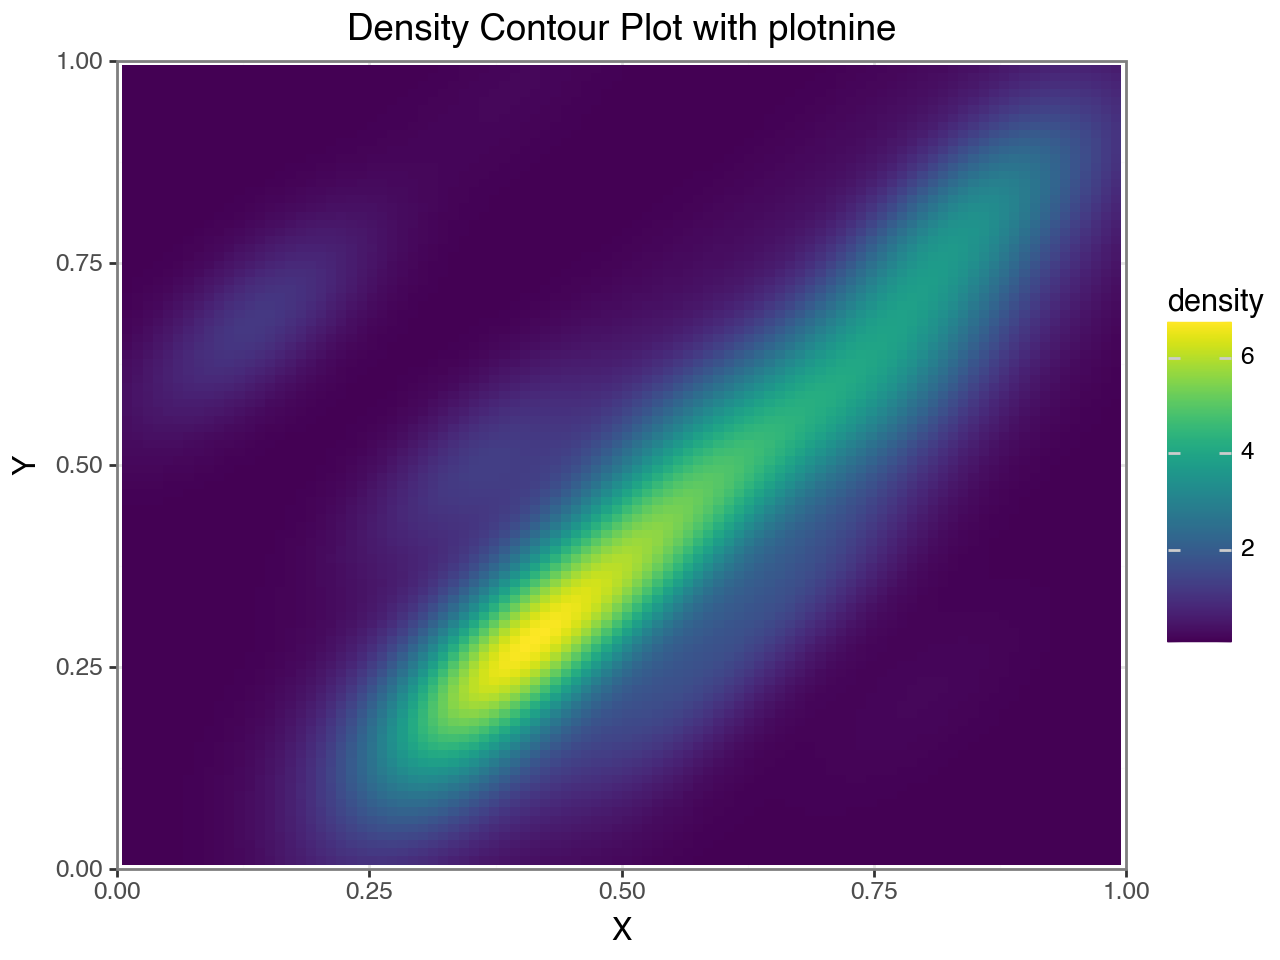

In [9]:
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_density_2d, geom_point, theme_minimal, labs, scale_x_continuous, scale_y_continuous, theme_bw, scale_fill_continuous, geom_tile, coord_cartesian 


method = "aCRN"
dfm = dfx[(dfx['method']==method)]
df = dfm


# Create the kde object
xy = np.vstack([dfm['p1'], dfm['p2']])
    # Evaluate the density on the grid
kde = gaussian_kde(xy)



# Create a grid for the contour plot
x_grid, y_grid = np.meshgrid(
    np.linspace(0, 1, 100),  # Set x limits from 0 to 1
    np.linspace(0, 1, 100)   # Set y limits from 0 to 1
)

# z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()]))



# Example DataFrame with x and y values
data = {
    'x': x_grid.ravel(),  # Ensure x values are between 0 and 1
    'y': y_grid.ravel(),   # Ensure y values are between 0 and 1
    'density': z
}
df = pd.DataFrame(data)



# Create the contour plot using plotnine
contour_plot = (
    ggplot(df, aes('x', 'y', fill = 'density')) +
    # geom_density_2d() +  # Unfilled contour plot
    geom_tile() +
    scale_fill_continuous() +
    coord_cartesian(expand=False) +
    # geom_point(alpha=0.5, color='black', size=0.5) +  # Overlay data points
    scale_x_continuous(limits=(0, 1)) +  # Set x-axis limits to 0 and 1
    scale_y_continuous(limits=(0, 1)) +  # Set y-axis limits to 0 and 1
    labs(
        title='Density Contour Plot with plotnine',
        x='X',
        y='Y'
    ) +
     
    theme_bw()  # Use a minimal theme for better aesthetics
)

# Display the plot
contour_plot

And with stat_density in plotnine

/Users/jozik/repos/adaptiveTS/.conda/lib/python3.12/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_raster : Removed 252 rows containing missing values.


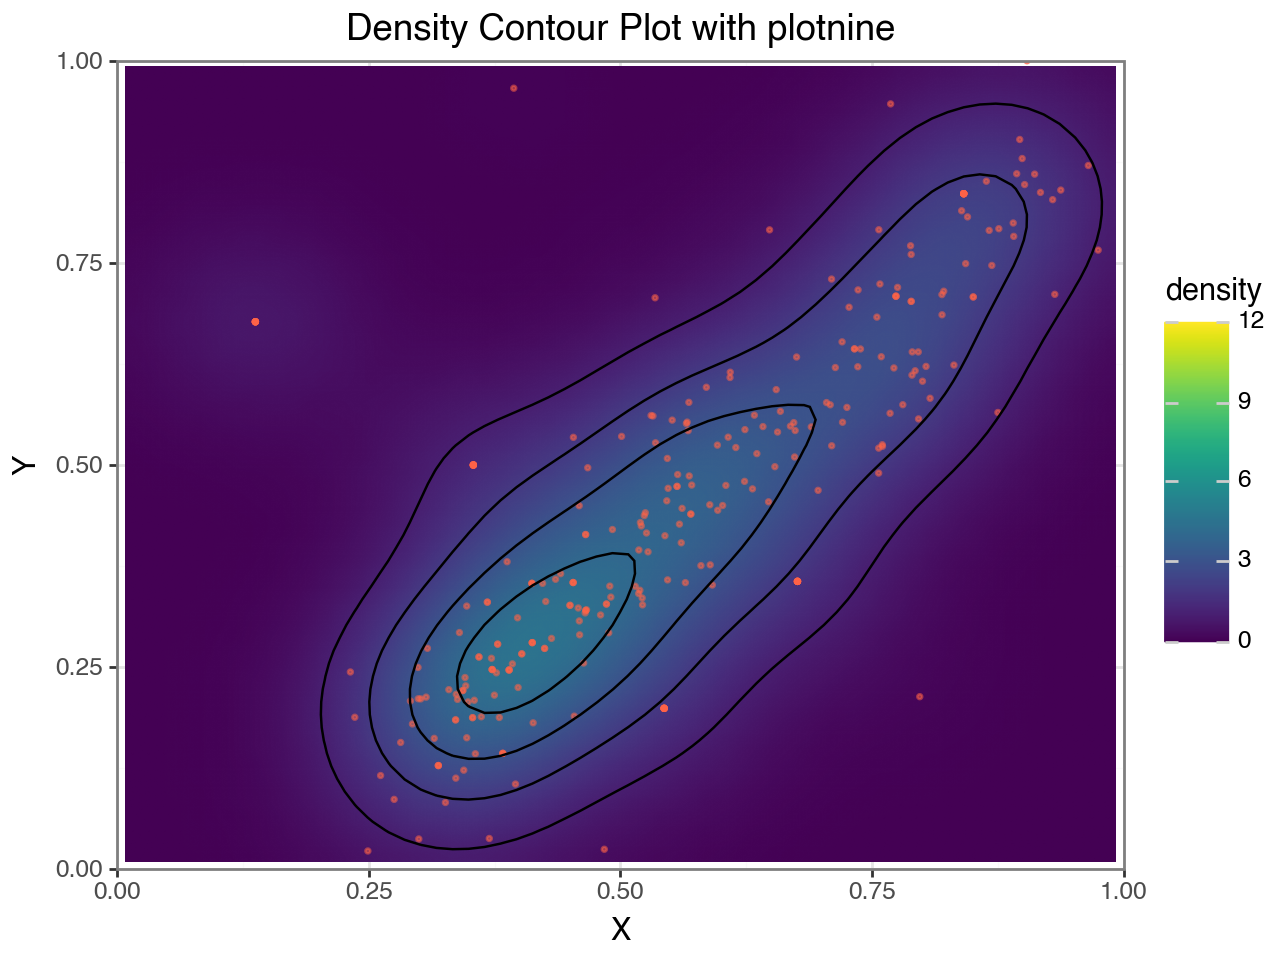

In [10]:
# Try with stat density

import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_density_2d, geom_point, theme_minimal, labs, scale_x_continuous, scale_y_continuous, theme_bw, scale_fill_continuous, geom_tile, stat_density_2d, after_stat


method = "aCRN"
dfm = dfx[(dfx['method']==method)]
df = dfm


# # Create the kde object
# xy = np.vstack([dfm['p1'], dfm['p2']])
#     # Evaluate the density on the grid
# kde = gaussian_kde(xy)



# # Create a grid for the contour plot
# x_grid, y_grid = np.meshgrid(
#     np.linspace(0, 1, 100),  # Set x limits from 0 to 1
#     np.linspace(0, 1, 100)   # Set y limits from 0 to 1
# )

# # z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
# z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()]))



# # Example DataFrame with x and y values
# data = {
#     'x': x_grid.ravel(),  # Ensure x values are between 0 and 1
#     'y': y_grid.ravel(),   # Ensure y values are between 0 and 1
#     'density': z
# }
# df = pd.DataFrame(data)



# Create the contour plot using plotnine
contour_plot = (
    ggplot(df, aes(x='p1', y='p2')) +
    # geom_density_2d() +  # Unfilled contour plot
    # geom_tile() +
    # stat_density_2d(aes(fill=after_stat('density')), geom='raster', contour=False) +
    # stat_density_2d(aes(fill='..density..'), geom='raster', contour=False) +
    
    # stat_density_2d(aes(fill='..density..'), geom='raster',interpolation='gaussian') +
    stat_density_2d(aes(fill=after_stat('density')), geom='raster', contour=False, interpolation='gaussian') +
    scale_fill_continuous(limits=(0,12)) +
    coord_cartesian(expand=False) +
    geom_point(alpha=0.5, color='tomato', size=0.5) +  # Overlay data points
    geom_density_2d() +  # Unfilled contour plot
    scale_x_continuous(limits=(0, 1)) +  # Set x-axis limits to 0 and 1
    scale_y_continuous(limits=(0, 1)) +  # Set y-axis limits to 0 and 1
    labs(
        title='Density Contour Plot with plotnine',
        x='X',
        y='Y'
    ) +
     
    theme_bw()  # Use a minimal theme for better aesthetics
)

# Display the plot
contour_plot

/Users/jozik/repos/adaptiveTS/.conda/lib/python3.12/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_raster : Removed 252 rows containing missing values.


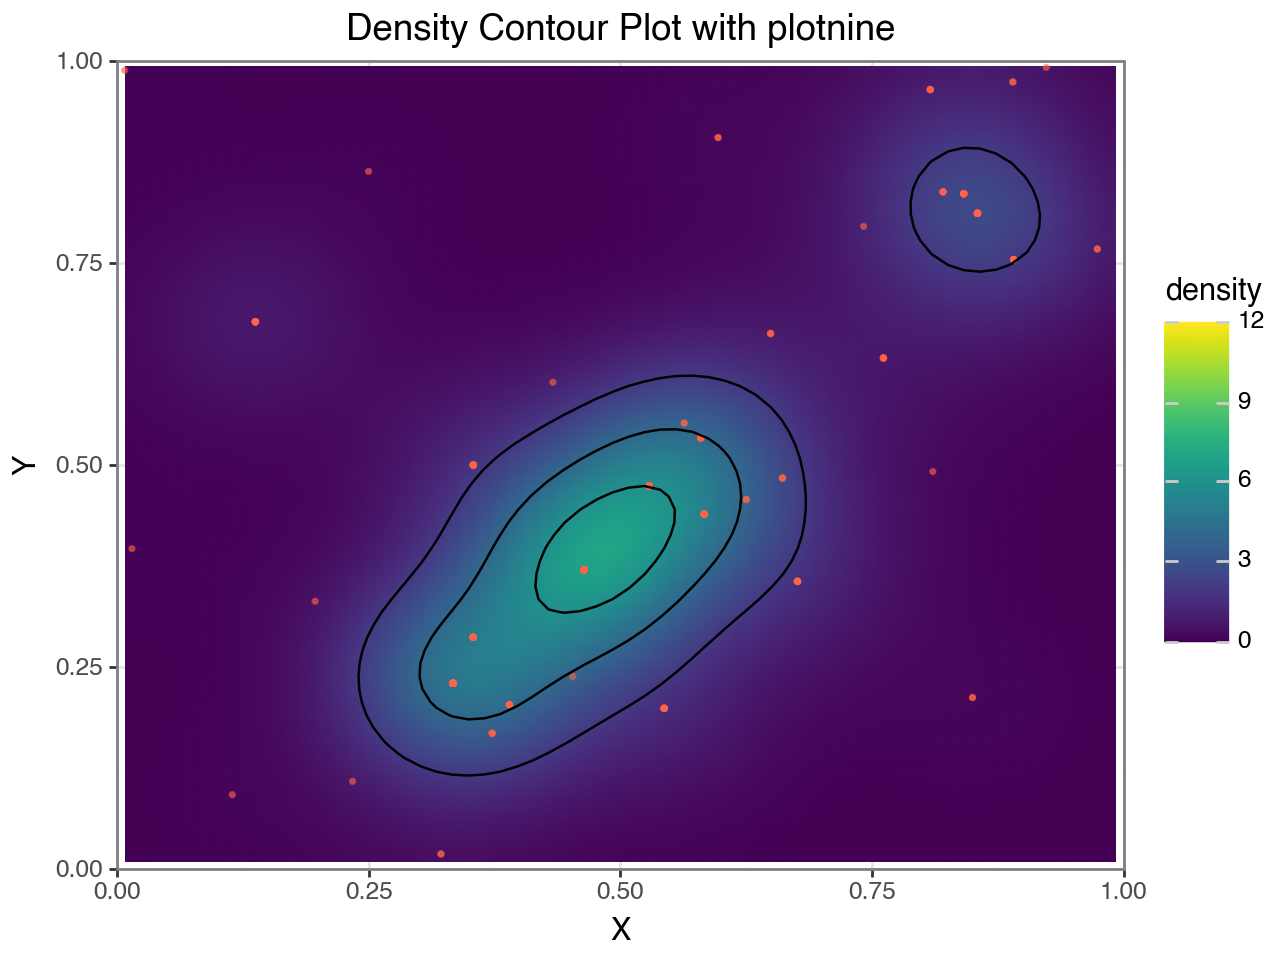

In [12]:
# Try with stat density

import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_density_2d, geom_point, theme_minimal, labs, scale_x_continuous, scale_y_continuous, theme_bw, scale_fill_continuous, geom_tile, stat_density_2d, after_stat


method = "fHet"
dfm = dfx[(dfx['method']==method)]
df = dfm


# # Create the kde object
# xy = np.vstack([dfm['p1'], dfm['p2']])
#     # Evaluate the density on the grid
# kde = gaussian_kde(xy)



# # Create a grid for the contour plot
# x_grid, y_grid = np.meshgrid(
#     np.linspace(0, 1, 100),  # Set x limits from 0 to 1
#     np.linspace(0, 1, 100)   # Set y limits from 0 to 1
# )

# # z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
# z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()]))



# # Example DataFrame with x and y values
# data = {
#     'x': x_grid.ravel(),  # Ensure x values are between 0 and 1
#     'y': y_grid.ravel(),   # Ensure y values are between 0 and 1
#     'density': z
# }
# df = pd.DataFrame(data)



# Create the contour plot using plotnine
contour_plot = (
    ggplot(df, aes(x='p1', y='p2')) +
    # geom_density_2d() +  # Unfilled contour plot
    # geom_tile() +
    # stat_density_2d(aes(fill=after_stat('density')), geom='raster', contour=False) +
    # stat_density_2d(aes(fill='..density..'), geom='raster', contour=False) +
    
    # stat_density_2d(aes(fill='..density..'), geom='raster',interpolation='gaussian') +
    stat_density_2d(aes(fill=after_stat('density')), geom='raster', contour=False, interpolation='gaussian') +
    scale_fill_continuous(limits=(0,12)) +
    coord_cartesian(expand=False) +
    geom_point(alpha=0.5, color='tomato', size=0.5) +  # Overlay data points
    geom_density_2d() +  # Unfilled contour plot
    scale_x_continuous(limits=(0, 1)) +  # Set x-axis limits to 0 and 1
    scale_y_continuous(limits=(0, 1)) +  # Set y-axis limits to 0 and 1
    labs(
        title='Density Contour Plot with plotnine',
        x='X',
        y='Y'
    ) +
     
    theme_bw()  # Use a minimal theme for better aesthetics
)

# Display the plot
contour_plot

Testing out ray-tracing figure for the 3d scatter-plots